In [2]:
import torch
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm


In [3]:
seed = 0 
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

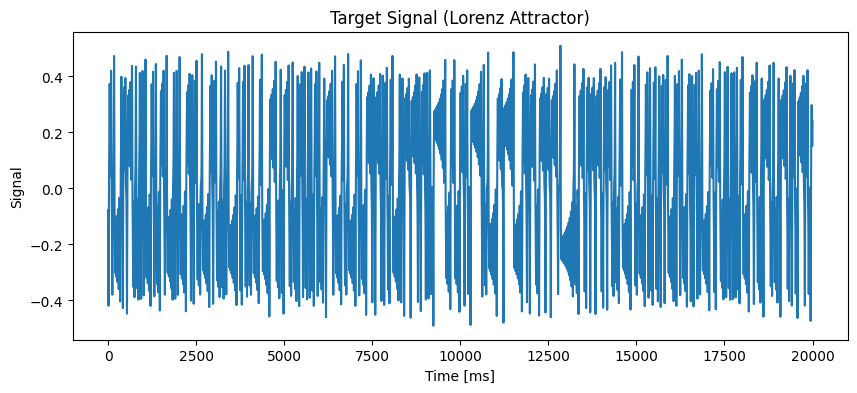

In [43]:
from rctorch.supervisors import LorenzAttractor
from rctorch.utils import minmax_transform

dt = 0.1 # [ms]
T = 20_000 # [ms]
t = np.arange(0, T, dt) # [ms]

lorenz = LorenzAttractor(T, dt, tau=0.02)
z_target = lorenz.generate(transient_time=1000)

z_target = torch.tensor(minmax_transform(z_target.T, zero_mean=True), dtype=torch.float32)

plt.figure(figsize=(10, 4))
plt.plot(t, z_target[:, 0])
plt.xlabel('Time [ms]')
plt.ylabel('Signal')
plt.title('Target Signal (Lorenz Attractor)')
plt.show()

In [74]:
N = 1000
g = 1.5
tau = 1
j_tg = torch.normal(mean=0, std=g/np.sqrt(N), size=(N, N))
j = j_tg.clone()
dim = z_target.size(1)
# w_... needs to be random uniform in [-1, 1]
w_tg_in = 2 * (torch.randn((N, dim)) - 1)
w_tg_fb = 2 * (torch.randn((N, dim)) - 1)
w_in = 2 * (torch.randn((N, dim)) - 1)

w_out = torch.zeros((N, dim))

# initial state of the network
x = torch.randn((N, 1))
x_tg = torch.randn((N, 1))
r = torch.tanh(x)
r_tg = torch.tanh(x_tg)

In [75]:
split = T * 0.6
nt_split = int(split // dt)

P = torch.eye(N) / 1.0
rls_step = 10

for i in tqdm(range(nt_split)):
    r_tg = torch.tanh(x_tg)
    I_tg = j_tg @ r_tg + w_tg_fb @ z_target[i].unsqueeze(1)
    x_tg += dt * (-x_tg + I_tg) * tau
    r = torch.tanh(x)
    I = j @ r
    x += dt * (-x + I) * tau
    if i % rls_step == 0:
        e_rec = j @ r - I_tg    # N x 1
        e_out = w_out.T @ r - z_target[i].unsqueeze(1)    # dim x 1
        P -= P @ r @ r.T @ P / (1 + r.T @ P @ r)
        w_out -= (P @ r @ e_out.T)
        j -= e_rec @ (P @ r).T

100%|██████████| 119999/119999 [03:12<00:00, 624.49it/s]


In [ ]:
split = T * 0.6
nt_split = int(split // dt)

P = torch.eye(N) / 1.0
rls_step = 10

for i in tqdm(range(nt_split)):
    r_tg = torch.tanh(x_tg)
    I_tg = j_tg @ r_tg + w_tg_fb @ z_target[i].unsqueeze(1)
    x_tg += dt * (-x_tg + I_tg) * tau
    r = torch.tanh(x)
    I = j @ r
    x += dt * (-x + I) * tau
    if i % rls_step == 0:
        e_rec = j @ r - I_tg    # N x 1
        e_out = w_out.T @ r - z_target[i].unsqueeze(1)    # dim x 1
        P -= P @ r @ r.T @ P / (1 + r.T @ P @ r)
        w_out -= (P @ r @ e_out.T)
        j -= e_rec @ (P @ r).T

100%|██████████| 119999/119999 [03:12<00:00, 624.49it/s]


In [76]:
z_out = torch.zeros(len(t) - nt_split, dim)
for i in tqdm(range(nt_split, len(t))):
    r = torch.tanh(x)
    x += dt * (-x + j @ r) * tau
    z_out[i - nt_split] = (w_out.T @ r).squeeze()

100%|██████████| 80001/80001 [00:15<00:00, 5297.69it/s]


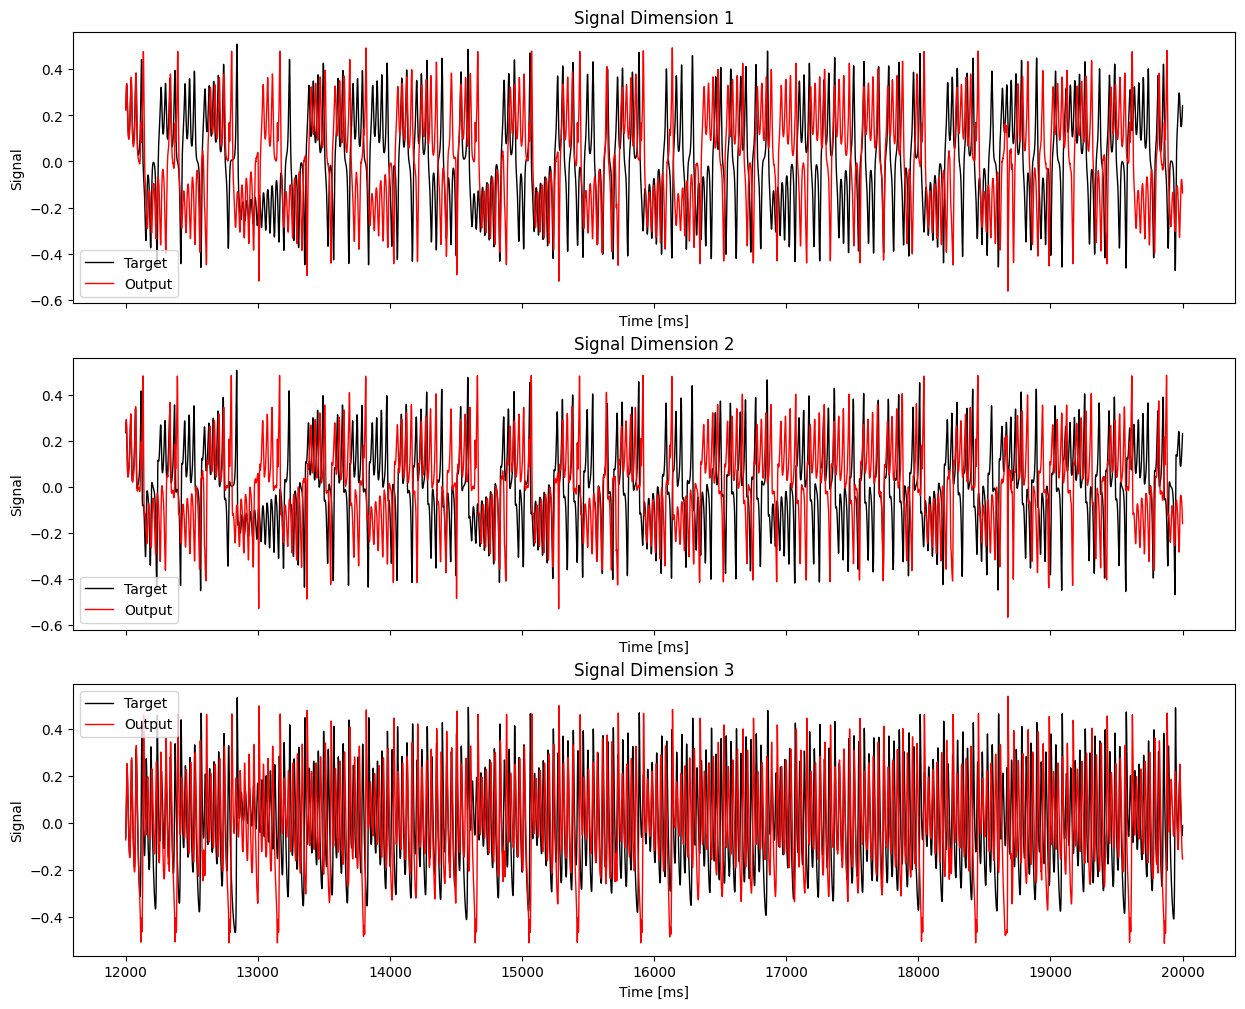

In [79]:
fig, ax = plt.subplots(dim, 1, figsize=(15, 4 * dim), sharex=True)

for i in range(dim):
    ax[i].plot(t[nt_split:], z_target[nt_split:, i], label='Target', lw=1, c='k')
    ax[i].plot(t[nt_split:], z_out[:, i], label='Output', lw=1, c='r')
    ax[i].set_xlabel('Time [ms]')
    ax[i].set_ylabel('Signal')
    ax[i].set_title(f'Signal Dimension {i+1}')
    ax[i].legend()

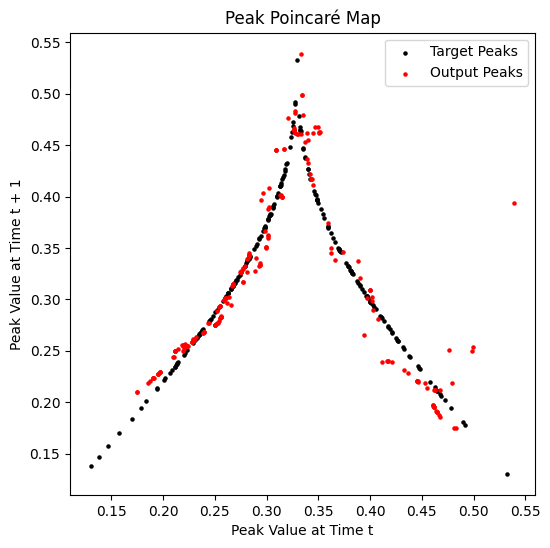

In [81]:
from scipy.signal import find_peaks

dist = 300
peaks, _ = find_peaks(z_out[:, -1], distance=dist)
z_peaks = z_out[:, -1][peaks]

# target during test
peaks_target, _ = find_peaks(z_target[nt_split:, -1], distance=dist)
z_peaks_target = z_target[nt_split:, -1][peaks_target]

plt.figure(figsize=(6, 6))
plt.scatter(z_peaks_target[:-1], z_peaks_target[1:], label='Target Peaks', c='k', s=5)
plt.scatter(z_peaks[:-1], z_peaks[1:], label='Output Peaks', c='r', s=5)
plt.xlabel('Peak Value at Time t')
plt.ylabel('Peak Value at Time t + 1')
plt.title('Peak Poincaré Map')
plt.legend()
plt.show()